In [ ]:
# Install libraries 
!pip install seaborn --quiet
!pip install missingno --quiet
!pip install imblearn --quiet
!pip install scikit-learn --quiet
!pip install --upgrade scipy statsmodels
!pip install ctgan

In [1]:
import os 
import sys
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings


sys.path.append(os.path.abspath(".."))

# Import functions 
import functions.wrangling as wrg
import functions.imputation as imp
import functions.eda as eda
import functions.eda_model as em

warnings.filterwarnings("ignore")

In [2]:
df = imp.load_data("bd_labs_imputed_within_2yrs.csv")
# Standardize the 'PerformedDate' by converting it to a 'VisitOrder' variable, grouping by patient and ordering their lab test records chronologically
df = df.sort_values(['Patient_ID', 'PerformedDate'])

Loaded dataset with shape: (318, 12)


In [3]:
df['Sex'] = df['Sex'].astype('category')
df['BD_Code'] = df['BD_Code'].astype('category')
df['Comorbidity'] = df['Comorbidity'].astype('category')

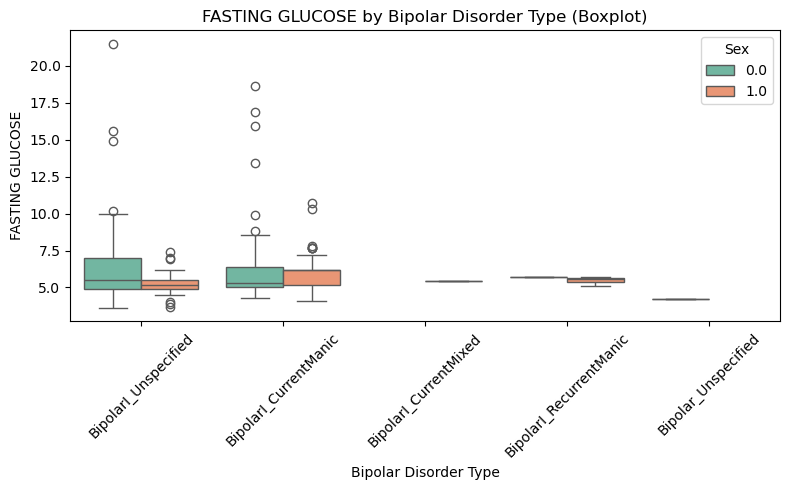

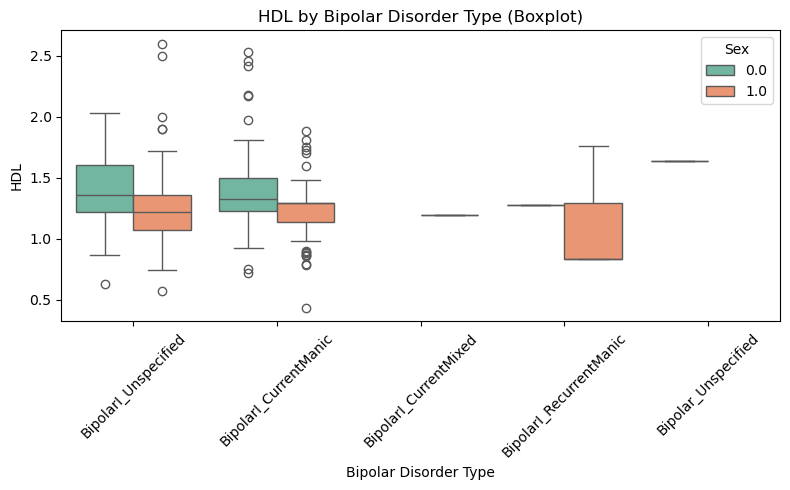

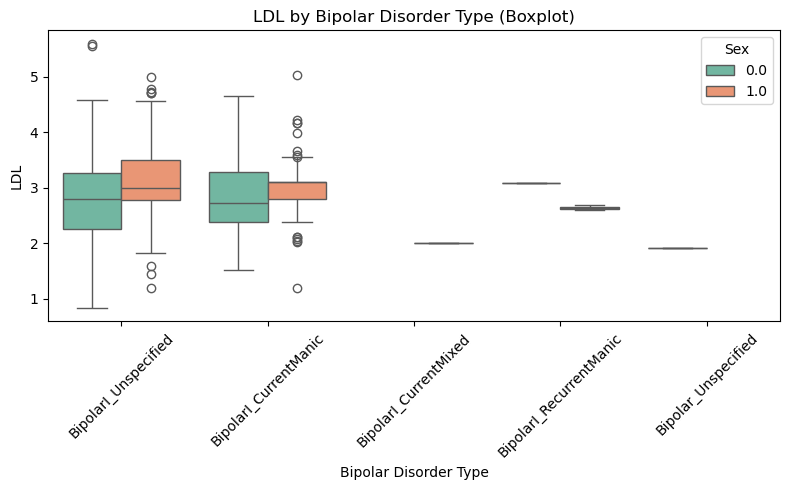

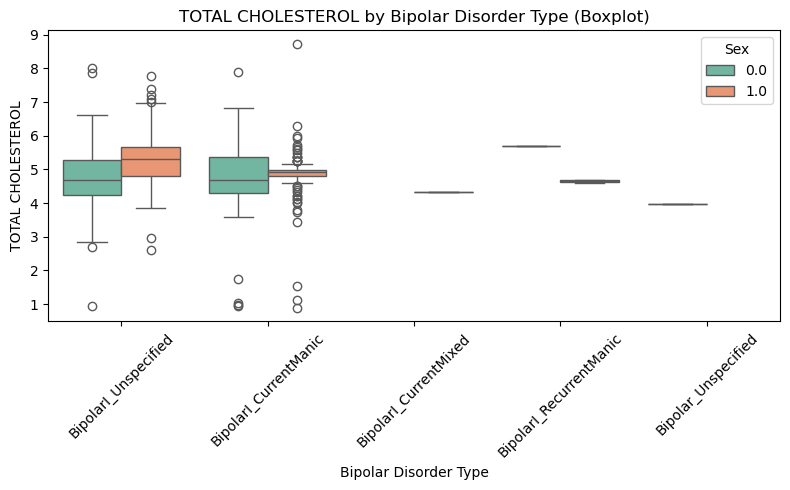

In [4]:
# Map and encode subtypes of bipolar disorders
bipolar_map = {
    '296.0': 'BipolarI_SingleManic',
    '296.1': 'BipolarI_RecurrentManic',
    '296.4': 'BipolarI_CurrentManic',
    '296.5': 'BipolarI_CurrentDepressed',
    '296.6': 'BipolarI_CurrentMixed',
    '296.7': 'BipolarI_Unspecified',
    '296.8': 'Bipolar_Unspecified'
}

bipolar_order = [
    'BipolarI_SingleManic',
    'BipolarI_RecurrentManic',
    'BipolarI_CurrentManic',
    'BipolarI_CurrentDepressed',
    'BipolarI_CurrentMixed',
    'BipolarI_Unspecified',
    'Bipolar_Unspecified'
]

df = em.map_encode(
    data=df,
    code='BD_Code',
    mapping_dict=bipolar_map,
    ordered_levels=bipolar_order,
    new_label='Bipolar Disorder Type',
    new_factor='Bipolar Disorder Type Factor',
    new_num='Bipolar Disorder Type Num'
)

em.plot_by_group(df, ['FASTING GLUCOSE', 'HDL', 'LDL','TOTAL CHOLESTEROL'], x='Bipolar Disorder Type',plot_type='box', hue="Sex")

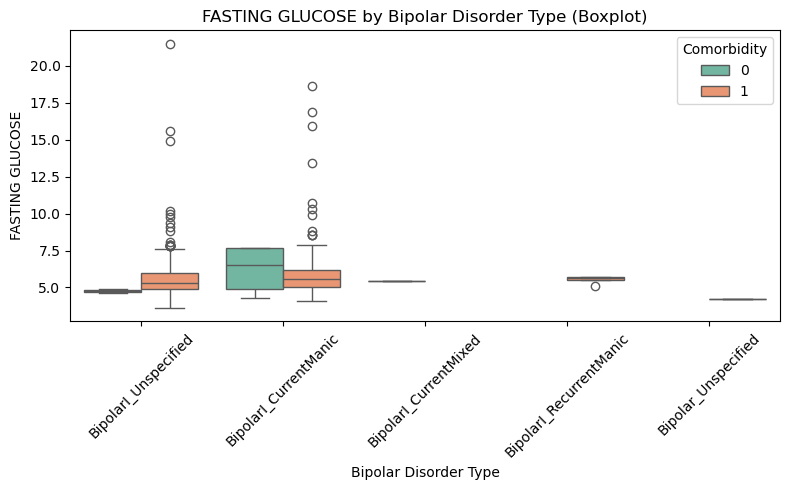

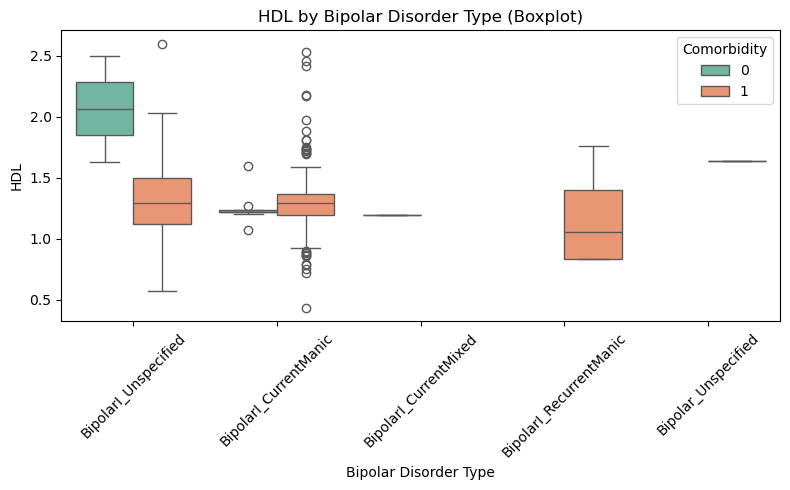

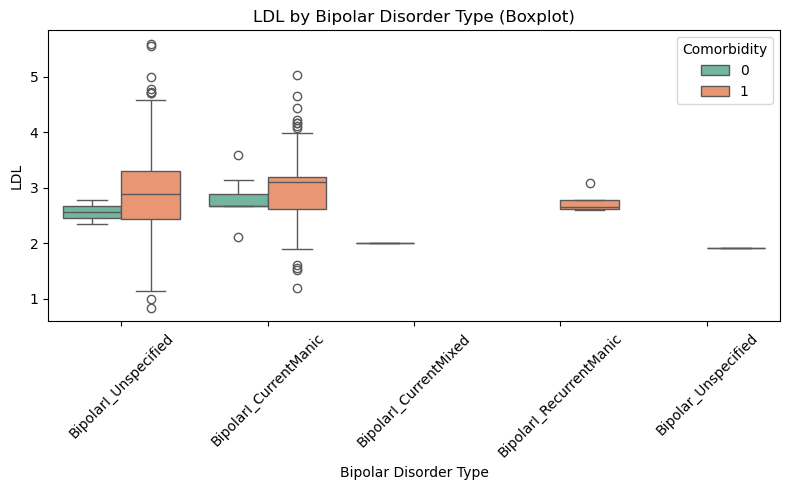

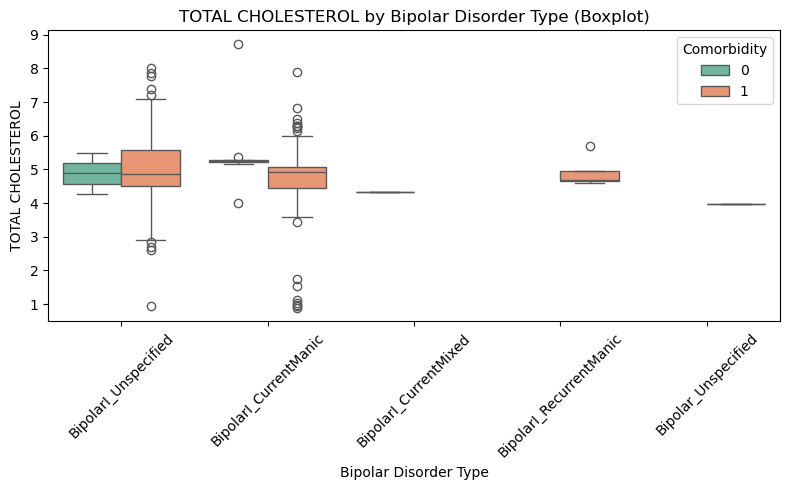

In [5]:
# EDA group by Comorbidity
em.plot_by_group(df, ['FASTING GLUCOSE', 'HDL', 'LDL','TOTAL CHOLESTEROL'], x='Bipolar Disorder Type',plot_type='box', hue="Comorbidity")

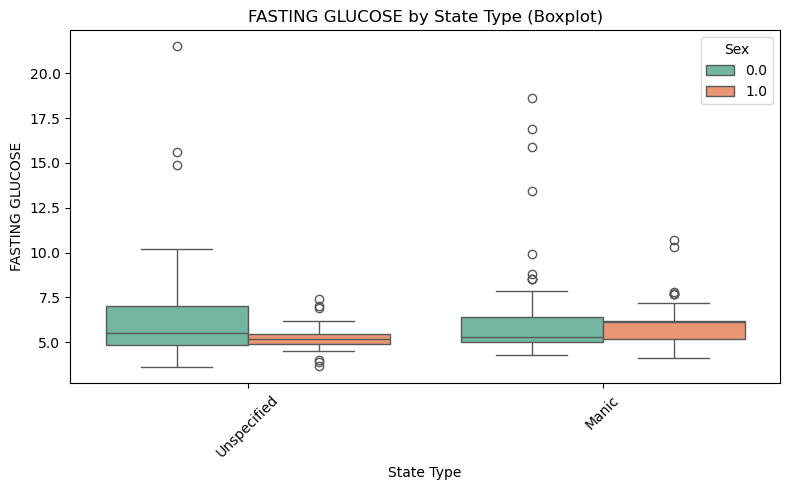

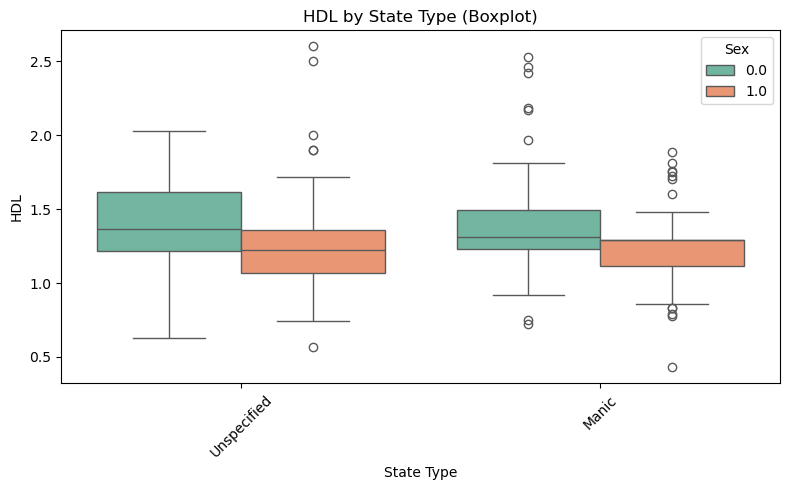

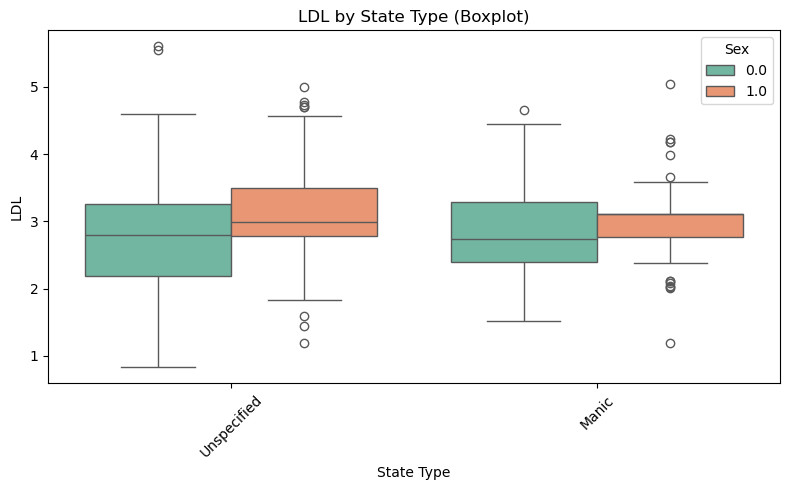

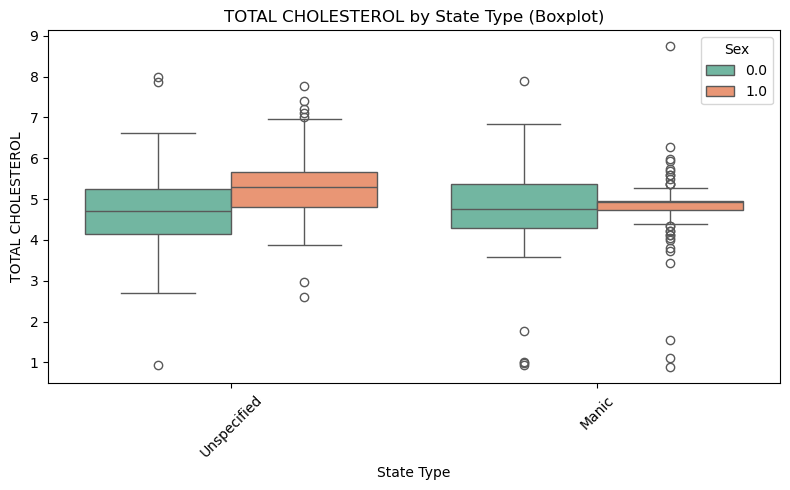

In [6]:
# Map and encode bipolar disorder states
state_map = {
    '296.0': 'Manic',         # BipolarI_SingleManic
    '296.1': 'Manic',         # BipolarI_RecurrentManic
    '296.4': 'Manic',         # BipolarI_CurrentManic
    '296.5': 'Depressed',     # BipolarI_CurrentDepressed
    '296.6': 'Manic',         # BipolarI_CurrentMixed (assigned to Manic, can adjust if needed)
    '296.7': 'Unspecified',   # BipolarI_Unspecified
    '296.8': 'Unspecified'    # Bipolar_Unspecified
}

state_order = ['Manic', 'Depressed', 'Unspecified']

df = em.map_encode(
    data=df,
    code='BD_Code',
    mapping_dict=state_map,
    ordered_levels=state_order,
    new_label='State Type',
    new_factor='State Type Factor',
    new_num='State Type Num'
)

em.plot_by_group(df, ['FASTING GLUCOSE', 'HDL', 'LDL','TOTAL CHOLESTEROL'], x='State Type',plot_type='box', hue="Sex")

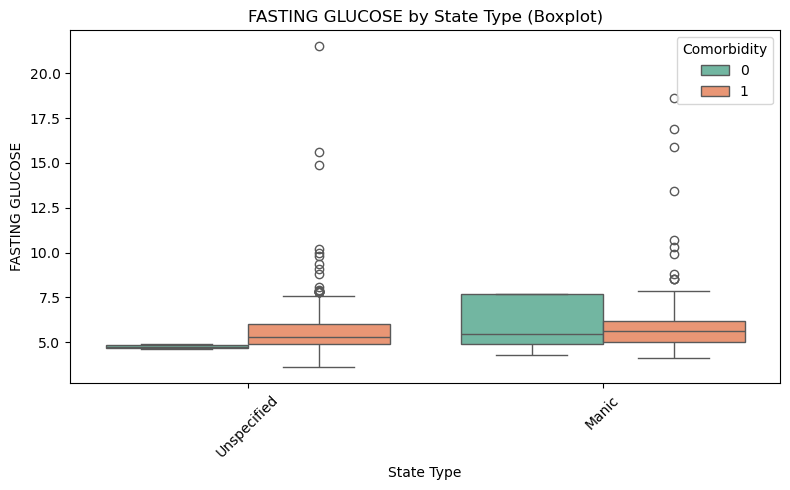

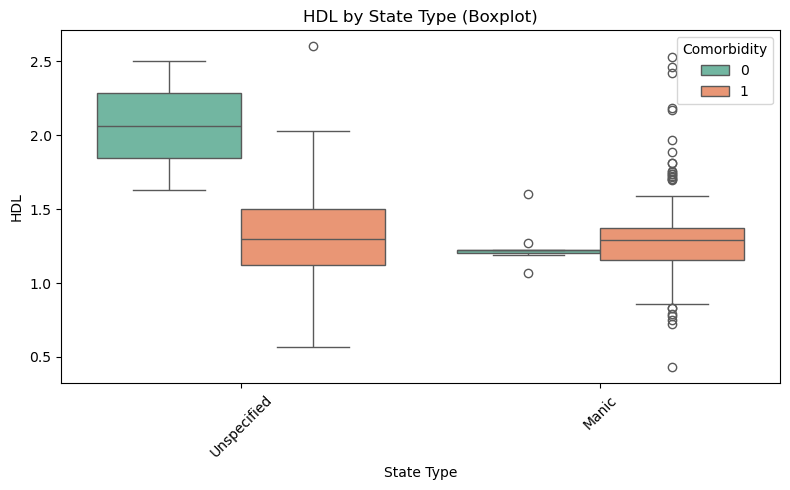

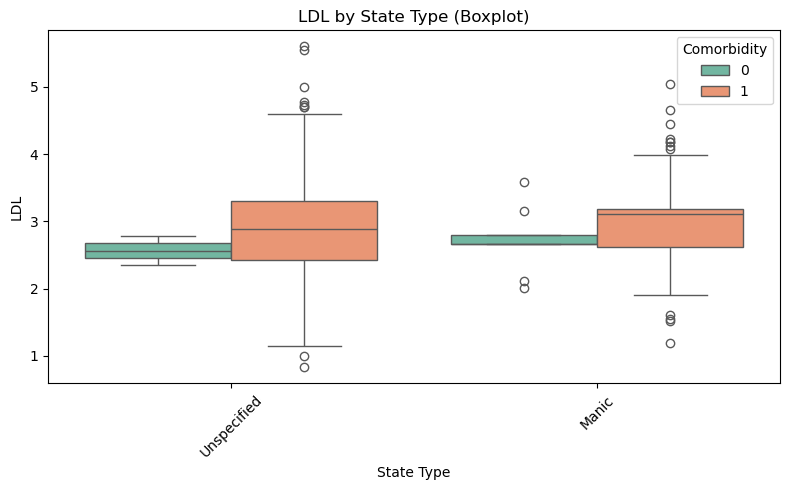

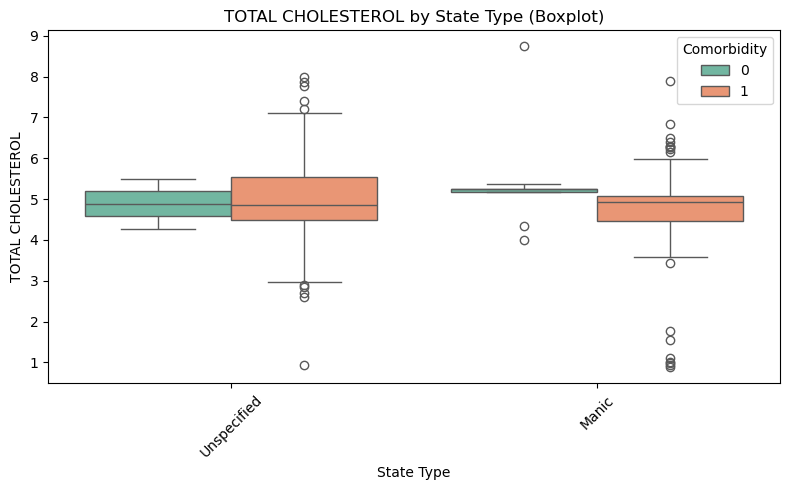

In [7]:
em.plot_by_group(df, ['FASTING GLUCOSE', 'HDL', 'LDL','TOTAL CHOLESTEROL'], x='State Type',plot_type='box', hue="Comorbidity")

In [8]:
# Kruskal-Wallis Test to see whether there are significant differences in the variable across multiple State_factor groups
em.kruskal_test(df, 
             variables= ['FASTING GLUCOSE', 'HDL', 'LDL','TOTAL CHOLESTEROL','Sex','Comorbidity','Age'], 
             group_col='Bipolar Disorder Type Factor')

FASTING GLUCOSE: H=4.886, p=0.0869
HDL: H=1.934, p=0.3802
LDL: H=1.268, p=0.5305
TOTAL CHOLESTEROL: H=1.284, p=0.5262
Sex: H=8.644, p=0.0133
Comorbidity: H=3.629, p=0.0568
Age: H=0.210, p=0.9002


,variable,n_groups,H_stat,p_value
0,FASTING GLUCOSE,3,4.885650,0.086915
1,HDL,3,1.934021,0.380218
2,LDL,3,1.267914,0.530489
3,TOTAL CHOLESTEROL,3,1.283985,0.526243
4,Sex,3,8.643591,0.013276
5,Comorbidity,2,3.628642,0.056793
6,Age,3,0.210166,0.900250


In [9]:
contingency_table_sex = pd.crosstab(df['Sex'], df['State Type Factor'])
print(contingency_table_sex)
contingency_table_comorbidity = pd.crosstab(df['Comorbidity'], df['State Type Factor'])
print(contingency_table_comorbidity)
with pd.ExcelWriter('contingency_tables.xlsx') as writer:
    contingency_table_sex.to_excel(writer, sheet_name='Sex_vs_State')
    contingency_table_comorbidity.to_excel(writer, sheet_name='Comorbidity_vs_State')

State Type Factor  Manic  Unspecified
Sex                                  
0.0                   72           95
1.0                   90           61
State Type Factor  Manic  Unspecified
Comorbidity                          
0                      9            2
1                    153          154


In [10]:
from scipy.stats import ttest_ind, chi2_contingency

group_col = 'State Type Factor'

cont_vars = ['FASTING GLUCOSE', 'HDL', 'LDL', 'TOTAL CHOLESTEROL', 'Age']
cat_vars = ['Sex', 'Comorbidity']

group1 = df[df[group_col] == 'Manic']
group2 = df[df[group_col] == 'Unspecified']

# T-tests for continuous variables
t_results = []
for var in cont_vars:
    stat, p_value = ttest_ind(group1[var].dropna(), group2[var].dropna(), equal_var=True)  # assuming equal variances
    t_results.append({
        'Variable': var,
        'Test': 'T-test',
        'Statistic': round(stat, 3),
        'p-value': round(p_value, 4)
    })

# Chi-square tests for categorical variables
chi2_results = []
for var in cat_vars:
    contingency_table = pd.crosstab(df[var], df[group_col])
    stat, p_value, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({
        'Variable': var,
        'Test': 'Chi-square',
        'Statistic': round(stat, 3),
        'p-value': round(p_value, 4)
    })

results_df = pd.DataFrame(t_results + chi2_results)

print("Group Comparison Test Results:")
print(results_df.to_string(index=False))

results_df.to_excel('group_comparison_test_results.xlsx', index=False)

print("Results have been saved to 'group_comparison_test_results.xlsx'.")


Group Comparison Test Results:
         Variable       Test  Statistic  p-value
  FASTING GLUCOSE     T-test      0.835   0.4043
              HDL     T-test     -1.190   0.2347
              LDL     T-test      0.234   0.8154
TOTAL CHOLESTEROL     T-test     -1.673   0.0953
              Age     T-test      1.998   0.0465
              Sex Chi-square      7.980   0.0047
      Comorbidity Chi-square      3.161   0.0754
Results have been saved to 'group_comparison_test_results.xlsx'.


In [21]:
# kmeans to do clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[['FASTING GLUCOSE', 'HDL', 'LDL', 'TOTAL CHOLESTEROL', 'Age','Sex','Comorbidity']].dropna()

# Fit K-Means, choose number of clusters, e.g., 3
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

# Add cluster labels back to DataFrame (align index if needed)
df_clusters = df.loc[X.index].copy()
df_clusters['Cluster'] = clusters
print(df_clusters['Cluster'].value_counts())

Cluster
0    236
1     82
Name: count, dtype: int64
Mean values by cluster:
         FASTING GLUCOSE       HDL       LDL  TOTAL CHOLESTEROL        Age  \
Cluster                                                                      
0               5.866771  1.320542  2.965229           4.908703  44.720339   
1               6.240732  1.325976  2.813146           4.772049  76.109756   

              Sex  Comorbidity  
Cluster                         
0        0.474576      0.95339  
1        0.475610      1.00000  

Median values by cluster:
         FASTING GLUCOSE    HDL    LDL  TOTAL CHOLESTEROL   Age  Sex  \
Cluster                                                                
0                   5.30  1.254  2.862              4.859  46.0  0.0   
1                   6.18  1.294  3.102              4.932  76.0  0.0   

         Comorbidity  
Cluster               
0                1.0  
1                1.0  


In [23]:
# mean & median of predictors in each cluster
df_clusters['Sex'] = df_clusters['Sex'].astype('category').cat.codes
df_clusters['Comorbidity'] = df_clusters['Comorbidity'].astype('category').cat.codes
num_cols = ['FASTING GLUCOSE', 'HDL', 'LDL', 'TOTAL CHOLESTEROL', 'Age', 'Sex', 'Comorbidity']
mean_by_cluster = df_clusters.groupby('Cluster')[num_cols].mean()
print("Mean values by cluster:")
print(mean_by_cluster)
median_by_cluster = df_clusters.groupby('Cluster')[num_cols].median()
print("\nMedian values by cluster:")
print(median_by_cluster)

mean_by_cluster.to_excel('mean_values_by_cluster.xlsx', engine='openpyxl')
median_by_cluster.to_excel('median_values_by_cluster.xlsx', engine='openpyxl')

Mean values by cluster:
         FASTING GLUCOSE       HDL       LDL  TOTAL CHOLESTEROL        Age  \
Cluster                                                                      
0               5.866771  1.320542  2.965229           4.908703  44.720339   
1               6.240732  1.325976  2.813146           4.772049  76.109756   

              Sex  Comorbidity  
Cluster                         
0        0.474576      0.95339  
1        0.475610      1.00000  

Median values by cluster:
         FASTING GLUCOSE    HDL    LDL  TOTAL CHOLESTEROL   Age  Sex  \
Cluster                                                                
0                   5.30  1.254  2.862              4.859  46.0  0.0   
1                   6.18  1.294  3.102              4.932  76.0  0.0   

         Comorbidity  
Cluster               
0                1.0  
1                1.0  


In [12]:
import scipy.stats as stats
import pandas as pd

# Contingency table
contingency_table = pd.crosstab(df_clusters['Cluster'], df_clusters['Bipolar Disorder Type Factor'])

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)

Chi-square statistic: 2.327018340609277
Degrees of freedom: 4
P-value: 0.6758543728073845


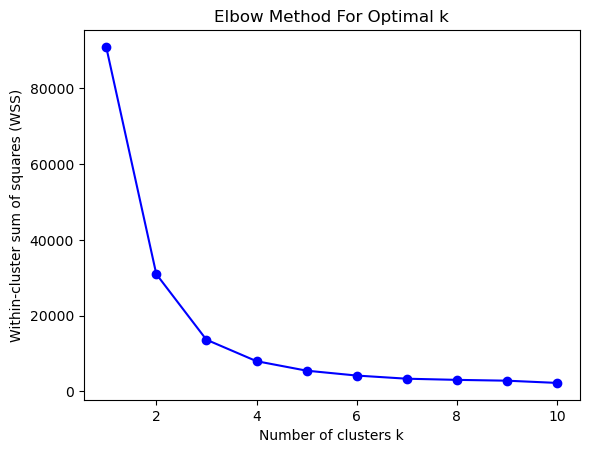

In [14]:
# elbow method for optimal k
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wss.append(kmeans.inertia_)

plt.plot(K_range, wss, 'bo-')
plt.xlabel('Number of clusters k')
plt.ylabel('Within-cluster sum of squares (WSS)')
plt.title('Elbow Method For Optimal k')
plt.show()


In [17]:
# visulization the confusion matrix
import pandas as pd

comparison_df = df.loc[X.index].copy()
comparison_df['Cluster'] = clusters

ct = pd.crosstab(comparison_df['Cluster'], comparison_df['State Type Factor'])
print(ct)
ct.to_excel("cluster_vs_state_confusion_matrix.xlsx", engine="openpyxl")

State Type Factor  Manic  Unspecified
Cluster                              
0                    119          117
1                     43           39


In [16]:
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

X = df[['FASTING GLUCOSE', 'HDL', 'LDL', 'TOTAL CHOLESTEROL', 'Age', 'Sex', 'Comorbidity']]
y = (df['State Type Factor'] == 'Manic').astype(int)
X['Sex'] = X['Sex'].astype('category').cat.codes
X['Comorbidity'] = X['Comorbidity'].astype('category').cat.codes

import statsmodels.api as sm
X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()
print(result.summary())
summary_table = result.summary2().tables[1]
summary_table.to_excel('logit_regression_results.xlsx', engine='openpyxl')

Optimization terminated successfully.
         Current function value: 0.655346
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:      State Type Factor   No. Observations:                  318
Model:                          Logit   Df Residuals:                      310
Method:                           MLE   Df Model:                            7
Date:                Mon, 21 Jul 2025   Pseudo R-squ.:                 0.05429
Time:                        18:38:07   Log-Likelihood:                -208.40
converged:                       True   LL-Null:                       -220.36
Covariance Type:            nonrobust   LLR p-value:                  0.001173
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.1026      1.268      0.869      0.385      -1.383       3.588
FASTING 

In [19]:
# SVM
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df[['FASTING GLUCOSE', 'HDL', 'LDL', 'TOTAL CHOLESTEROL', 'Age','Sex','Comorbidity']].dropna()

X['Sex'] = X['Sex'].astype('category').cat.codes
X['Comorbidity'] = X['Comorbidity'].astype('category').cat.codes

y = df.loc[X.index, 'State Type Factor']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

svm = SVC(random_state=42)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       Manic       0.75      0.38      0.51        47
 Unspecified       0.60      0.88      0.71        49

    accuracy                           0.64        96
   macro avg       0.67      0.63      0.61        96
weighted avg       0.67      0.64      0.61        96

